# DS Automation Assignment

# Task 1
Using our prepared churn data from week 2:
- use pycaret to find an ML algorithm that performs best on the data
    - Choose a metric you think is best to use for finding the best model; by default, it is accuracy but it could be AUC, precision, recall, etc. The week 3 FTE has some information on these different metrics.
- save the model to disk
- create a Python script/file/module with a function that takes a pandas dataframe as an input and returns the probability of churn for each row in the dataframe
    - your Python file/function should print out the predictions for new data (new_churn_data.csv)
    - the true values for the new data are [1, 0, 0, 1, 0] if you're interested
- test your Python module and function with the new data, new_churn_data.csv
- write a short summary of the process and results at the end of this notebook
- upload this Jupyter Notebook and Python file to a Github repository, and turn in a link to the repository in the week 5 assignment dropbox

Additional challenges:
- return the probability of churn for each new prediction, and the percentile where that prediction is in the distribution of probability predictions from the training dataset (e.g. a high probability of churn like 0.78 might be at the 90th percentile)
- use other autoML packages, such as TPOT, H2O, MLBox, etc, and compare performance and features with pycaret
- create a class in your Python module to hold the functions that you created
- accept user input to specify a file using a tool such as Python's `input()` function, the `click` package for command-line arguments, or a GUI
- Use the unmodified churn data (new_unmodified_churn_data.csv) in your Python script. This will require adding the same preprocessing steps from week 2 since this data is like the original unmodified dataset from week 1.


# Task 2: Critical Reflection
What are your observations based on the analyses you had performed? Is there one model that seems particularly useful for predicting churn. Why or why not?

An observation that can be made is that no single model dominated on all metrics, so the "best" model depends on what it is optimized for. Sorting by AUC, the linear and boosting models clustered tightly at the top, where Gradient Boosting, AdaBoost, and Logistic Regression all landed around 0.83 to 0.84 AUC with about 0.79 accuracy. Gradient Boosting came out slightly ahead on AUC, which is why it was chosen, but the differences among the top few are small enough that any of them could've been a fine choice, plus the simple Logistic Regression would also be nice since it is fast and interpretable while performing nearly identical.

There was also a split when it came to recall. The top-AUC models all had modest recall (around 0.48 to 0.51), so they miss roughly half the churners at the default threshold, whereas Quadratic Discriminant Analysis and Naive Bayes had much a better recall (around 0.70) at the cost of lower precision and overall accuracy. So there is no one model that would qualify as universally the "most useful" for predicting churn. If the business goal is to catch as many churners as possible, a higher-recall model (or lowering the threshold on the gradient boosting model) is more useful than chasing the top AUC. Gradient Boosting would be the pick as the best general rank here because AUC captures how well it separates churners from non-churners independent of threshold, and the threshold can then be tuned to hit whatever recall the retention team needs.

### Task 1A - use pycaret to find an ML algorithm that performs best on the data


In [1]:
##imports

import pandas as pd
from pycaret.classification import (
    setup, compare_models, pull, finalize_model, save_model, load_model, predict_model
)

In [2]:
# Week 2/3 prepared training data (as saved from earlier weeks)

train_raw = pd.read_csv('../Week 3/cleaned_churn_data.csv', index_col='customerID')
print('training columns:', list(train_raw.columns))
train_raw.head()

training columns: ['tenure', 'PhoneService', 'Contract', 'MonthlyCharges', 'TotalCharges', 'Churn', 'Payment_Bank transfer (automatic)', 'Payment_Credit card (automatic)', 'Payment_Electronic check', 'Payment_Mailed check', 'charges_per_month_tenure']


,tenure,PhoneService,Contract,MonthlyCharges,TotalCharges,Churn,Payment_Bank transfer (automatic),Payment_Credit card (automatic),Payment_Electronic check,Payment_Mailed check,charges_per_month_tenure
customerID,,,,,,,,,,,
7590-VHVEG,1,0,0,29.85,29.85,0,0,0,1,0,29.850000
5575-GNVDE,34,1,1,56.95,1889.50,0,0,0,0,1,55.573529
3668-QPYBK,2,1,0,53.85,108.15,1,0,0,0,1,54.075000
7795-CFOCW,45,0,1,42.30,1840.75,0,1,0,0,0,40.905556
9237-HQITU,2,1,0,70.70,151.65,1,0,0,1,0,75.825000


In [4]:
# New data to score
new_raw = pd.read_csv('new_churn_data.csv', index_col='customerID')
print('new data columns:', list(new_raw.columns))
new_raw.head()

new data columns: ['tenure', 'PhoneService', 'Contract', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'charge_per_tenure']


,tenure,PhoneService,Contract,PaymentMethod,MonthlyCharges,TotalCharges,charge_per_tenure
customerID,,,,,,,
9305-CKSKC,22,1,0,2,97.40,811.70,36.895455
1452-KNGVK,8,0,1,1,77.30,1701.95,212.743750
6723-OKKJM,28,1,0,0,28.25,250.90,8.960714
7832-POPKP,62,1,0,2,101.70,3106.56,50.105806
6348-TACGU,10,0,0,1,51.15,3440.97,344.097000


### The two `head()` outputs have a mismatch:

To fix this I retrain on a feature set that matches the new data. I collapse the four Payment column one-hots back into a single integer PaymentMethod column (using the same codes the new data uses: Credit card = 0, Mailed check = 1, Electronic check = 2, Bank transfer = 3) and rename `charges_per_month_tenure` to `charge_per_tenure`

In [5]:
payment_codes = {
    'Payment_Credit card (automatic)': 0,
    'Payment_Mailed check': 1,
    'Payment_Electronic check': 2,
    'Payment_Bank transfer (automatic)': 3,
}

df = train_raw.copy()
df['PaymentMethod'] = 0
for col, code in payment_codes.items():
    df.loc[df[col] == 1, 'PaymentMethod'] = code
df = df.drop(columns=list(payment_codes.keys()))
df = df.rename(columns={'charges_per_month_tenure': 'charge_per_tenure'})

df = df[['tenure', 'PhoneService', 'Contract', 'PaymentMethod',
         'MonthlyCharges', 'TotalCharges', 'charge_per_tenure', 'Churn']]

print('prepared training columns:', list(df.columns))
print('new data feature columns :', list(new_raw.columns))
df.head()

prepared training columns: ['tenure', 'PhoneService', 'Contract', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'charge_per_tenure', 'Churn']
new data feature columns : ['tenure', 'PhoneService', 'Contract', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'charge_per_tenure']


,tenure,PhoneService,Contract,PaymentMethod,MonthlyCharges,TotalCharges,charge_per_tenure,Churn
customerID,,,,,,,,
7590-VHVEG,1,0,0,2,29.85,29.85,29.850000,0
5575-GNVDE,34,1,1,1,56.95,1889.50,55.573529,0
3668-QPYBK,2,1,0,1,53.85,108.15,54.075000,1
7795-CFOCW,45,0,1,3,42.30,1840.75,40.905556,0
9237-HQITU,2,1,0,2,70.70,151.65,75.825000,1


In [ ]:
automl = setup(data=df, target='Churn', session_id=42)

,Description,Value
0,Session id,42
1,Target,Churn
2,Target type,Binary
3,Original data shape,"(7043, 8)"
4,Transformed data shape,"(7043, 8)"
5,Transformed train set shape,"(4930, 8)"
6,Transformed test set shape,"(2113, 8)"
7,Numeric features,7
8,Preprocess,True
9,Imputation type,simple


In [10]:
## using AUC to determine which model

which_model = compare_models(sort='AUC')
leaderboard = pull()
leaderboard

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
gbc,Gradient Boosting Classifier,0.7915,0.8366,0.4794,0.6443,0.5489,0.4173,0.4254,0.0490
ada,Ada Boost Classifier,0.7941,0.8350,0.5108,0.6423,0.5676,0.4351,0.4408,0.0160
lr,Logistic Regression,0.7947,0.8325,0.5146,0.6423,0.5703,0.4378,0.4431,0.0140
lightgbm,Light Gradient Boosting Machine,0.7874,0.8236,0.5008,0.6268,0.5558,0.4184,0.4236,0.2990
ridge,Ridge Classifier,0.7901,0.8191,0.4542,0.6515,0.5340,0.4042,0.4158,0.0040
lda,Linear Discriminant Analysis,0.7846,0.8191,0.4909,0.6202,0.5476,0.4087,0.4138,0.0040
qda,Quadratic Discriminant Analysis,0.7521,0.8175,0.7233,0.5255,0.6081,0.4339,0.4461,0.0040
nb,Naive Bayes,0.7442,0.8148,0.7042,0.5149,0.5942,0.4144,0.4256,0.0030
rf,Random Forest Classifier,0.7801,0.8052,0.4855,0.6082,0.5394,0.3975,0.4021,0.0430
et,Extra Trees Classifier,0.7606,0.7795,0.4786,0.5580,0.5145,0.3571,0.3594,0.0300


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
gbc,Gradient Boosting Classifier,0.7915,0.8366,0.4794,0.6443,0.5489,0.4173,0.4254,0.049
ada,Ada Boost Classifier,0.7941,0.8350,0.5108,0.6423,0.5676,0.4351,0.4408,0.016
lr,Logistic Regression,0.7947,0.8325,0.5146,0.6423,0.5703,0.4378,0.4431,0.014
lightgbm,Light Gradient Boosting Machine,0.7874,0.8236,0.5008,0.6268,0.5558,0.4184,0.4236,0.299
ridge,Ridge Classifier,0.7901,0.8191,0.4542,0.6515,0.5340,0.4042,0.4158,0.004
lda,Linear Discriminant Analysis,0.7846,0.8191,0.4909,0.6202,0.5476,0.4087,0.4138,0.004
qda,Quadratic Discriminant Analysis,0.7521,0.8175,0.7233,0.5255,0.6081,0.4339,0.4461,0.004
nb,Naive Bayes,0.7442,0.8148,0.7042,0.5149,0.5942,0.4144,0.4256,0.003
rf,Random Forest Classifier,0.7801,0.8052,0.4855,0.6082,0.5394,0.3975,0.4021,0.043
et,Extra Trees Classifier,0.7606,0.7795,0.4786,0.5580,0.5145,0.3571,0.3594,0.030


In [11]:
which_model

GradientBoostingClassifier(ccp_alpha=0.0, criterion='friedman_mse', init=None,
                           learning_rate=0.1, loss='log_loss', max_depth=3,
                           max_features=None, max_leaf_nodes=None,
                           min_impurity_decrease=0.0, min_samples_leaf=1,
                           min_samples_split=2, min_weight_fraction_leaf=0.0,
                           n_estimators=100, n_iter_no_change=None,
                           random_state=42, subsample=1.0, tol=0.0001,
                           validation_fraction=0.1, verbose=0,
                           warm_start=False)

### Task 1B - save the model to disk

In [9]:
final_model = finalize_model(which_model)
save_model(final_model, 'churn_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['tenure', 'PhoneService',
                                              'Contract', 'PaymentMethod',
                                              'MonthlyCharges', 'TotalCharges',
                                              'charge_per_tenure'],
                                     transformer=SimpleImputer(add_indicator=False,
                                                               copy=True,
                                                               fill_value=None,
                                                               keep_empty_features=False,
                                                               missing_values=nan,
                                                               strategy='mean'))),
                 ('c...
                                             criterion='f

### Task 1C/D - create a Python script/file/module with a function that takes a pandas dataframe as an input and returns the probability of churn for each row in the dataframe

Using `raw_score=True` gives a probability column for each class; `prediction_score_1` is the probability of churn

In [13]:
new_data = pd.read_csv('new_churn_data.csv', index_col='customerID')
scored = predict_model(final_model, data=new_data, raw_score=True)

results = pd.DataFrame(index=new_data.index)
results['churn_probability'] = scored['prediction_score_1'].round(4)
results['churn_prediction'] = scored['prediction_label'].map({1: 'Churn', 0: 'No churn'})
results['true_label'] = [1, 0, 0, 1, 0]
results

,churn_probability,churn_prediction,true_label
customerID,,,
9305-CKSKC,0.4377,No churn,1
1452-KNGVK,0.0671,No churn,0
6723-OKKJM,0.0926,No churn,0
7832-POPKP,0.2723,No churn,1
6348-TACGU,0.0958,No churn,0


## Lowering the decision threshold

Feedback on my week 4 assignment suggested lowering the threshold. The five churn probabilities above are `[0.44, 0.07, 0.09, 0.27, 0.10]` against true labels `[1, 0, 0, 1, 0]`, so the two real churners have the two highest scores but both sit below 0.5. Compare the threshold at 0.5, 0.4, and 0.25

In [15]:
proba = scored['prediction_score_1']
true = pd.Series([1, 0, 0, 1, 0], index=proba.index)

rows = []
for thr in [0.50, 0.40, 0.25]:
    preds = (proba >= thr).astype(int)
    tp = int(((preds == 1) & (true == 1)).sum())
    fp = int(((preds == 1) & (true == 0)).sum())
    fn = int(((preds == 1).eq(False) & (true == 1)).sum())
    correct = int((preds == true).sum())
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    precision = tp / (tp + fp) if (tp + fp) else float('nan')
    rows.append({
        'threshold': thr,
        'predictions': list(preds.values),
        'churners_caught': f'{tp}/2',
        'correct': f'{correct}/5',
        'churn_recall': round(recall, 2),
        'churn_precision': round(precision, 2) if precision == precision else None,
    })

threshold_comparison = pd.DataFrame(rows)
threshold_comparison

,threshold,predictions,churners_caught,correct,churn_recall,churn_precision
0,0.50,"[0, 0, 0, 0, 0]",0/2,3/5,0.0,NaN
1,0.40,"[1, 0, 0, 0, 0]",1/2,4/5,0.5,1.0
2,0.25,"[1, 0, 0, 1, 0]",2/2,5/5,1.0,1.0


At **0.50** (default) neither churner is flagged (3/5 correct). At **0.40** the first churner at 0.44 is caught (4/5). At **0.25** the second churner at 0.27 is also caught, so all five are classified correctly (5/5)

### Test the Python module

In [16]:
import predict_churn

predictor = predict_churn.ChurnPredictor()
new_df = predictor.load_data('new_churn_data.csv')
predictor.make_predictions(new_df)

Transformation Pipeline and Model Successfully Loaded


,churn_probability,churn_prediction,train_percentile
customerID,,,
9305-CKSKC,0.4377,No churn,74.7
1452-KNGVK,0.0671,No churn,29.3
6723-OKKJM,0.0926,No churn,36.4
7832-POPKP,0.2723,No churn,59.6
6348-TACGU,0.0958,No churn,37.1


# Additional Challenges

## Challenge 1 - return the probability of churn for each new prediction, and the percentile where that prediction is in the distribution of probability predictions from the training dataset (e.g. a high probability of churn like 0.78 might be at the 90th percentile)

In [12]:
# Churn probabilities the model assigns across the whole training set.
train_features = df.drop(columns=['Churn'])
train_scored = predict_model(final_model, data=train_features, raw_score=True)
train_probs = train_scored['prediction_score_1'].values

# Percentile of each new prediction within that training distribution.
new_probs = scored['prediction_score_1'].values
percentiles = [round(float((train_probs <= p).mean() * 100), 1) for p in new_probs]

results_pct = results.copy()
results_pct['train_percentile'] = percentiles
results_pct

,churn_probability,churn_prediction,true_label,train_percentile
customerID,,,,
9305-CKSKC,0.4377,No churn,1,74.7
1452-KNGVK,0.0671,No churn,0,29.3
6723-OKKJM,0.0926,No churn,0,36.4
7832-POPKP,0.2723,No churn,1,59.6
6348-TACGU,0.0958,No churn,0,37.1


The churner at probability 0.44 sits around the 75th percentile of training probabilities, and the 0.27 customer around the 60th, while the three clear non-churners land in the bottom half. So even though the default 0.5 threshold labels all five "No churn," the percentile view makes it obvious that the two true churners are the highest-risk of the group

## Challenge 2: compare pycaret with H2O AutoML

I compare pycaret's chosen model against H2O (the autoML package used last week) on the same matched-schema churn data. H2O runs on a JVM, so the cell sets `JAVA_HOME` to the Java runtime installed in this environment before starting the cluster.

In [13]:
import os
os.environ['JAVA_HOME'] = os.path.expanduser('~/miniconda3/envs/msds/lib/jvm')

import h2o
from h2o.estimators import H2ORandomForestEstimator

h2o.init(max_mem_size='2G')

Checking whether there is an H2O instance running at http://localhost:54321.

.

.

.

.

 not found.
Attempting to start a local H2O server...
  Java Version: openjdk version "25.0.2" 2026-01-20 LTS; OpenJDK Runtime Environment Zulu25.32+21-CA (build 25.0.2+10-LTS); OpenJDK 64-Bit Server VM Zulu25.32+21-CA (build 25.0.2+10-LTS, mixed mode, sharing)
  Starting server from /Users/P3074606/miniconda3/envs/msds/lib/python3.10/site-packages/h2o/backend/bin/h2o.jar
  Ice root: /var/folders/p3/vtsy_rbn4tj2zzs5mt11_czr0000gp/T/tmp3yfexw5k
  JVM stdout: /var/folders/p3/vtsy_rbn4tj2zzs5mt11_czr0000gp/T/tmp3yfexw5k/h2o_P3074606_started_from_python.out
  JVM stderr: /var/folders/p3/vtsy_rbn4tj2zzs5mt11_czr0000gp/T/tmp3yfexw5k/h2o_P3074606_started_from_python.err


  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ...

 successful.


H2O_cluster_uptime:,01 secs
H2O_cluster_timezone:,America/Denver
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.12
H2O_cluster_version_age:,1 month and 17 days
H2O_cluster_name:,H2O_from_python_P3074606_rjhagr
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,1.983 Gb
H2O_cluster_total_cores:,10
H2O_cluster_allowed_cores:,10
H2O_cluster_status:,"locked, healthy"



+------------------------------------------------------------------+
| You are running the community edition of H2O-3 OSS.              |
|                                                                  |
| For commercial use, H2O-3 Secure is now recommended.             |
| This includes production support, CVE fixes, multi-node scaling, |
| model artifact extraction, and more.                             |
| See h2o.ai/h2o-3/oss-vs-secure for additional details.           |
| Contact enterprise@h2o.ai to upgrade.                            |
+------------------------------------------------------------------+


In [14]:
# Same matched-schema data, split into train/test for H2O.
hf = h2o.H2OFrame(df.reset_index(drop=True))
hf['Churn'] = hf['Churn'].asfactor()  # classification target

features = [c for c in hf.columns if c != 'Churn']
train_hf, test_hf = hf.split_frame(ratios=[0.7], seed=42)

rf = H2ORandomForestEstimator(ntrees=100, seed=42)
rf.train(x=features, y='Churn', training_frame=train_hf, validation_frame=test_hf)

h2o_auc = rf.model_performance(test_hf).auc()
h2o_acc = rf.model_performance(test_hf).accuracy()[0][1]
print('H2O random forest test AUC     :', round(h2o_auc, 4))
print('H2O random forest test accuracy:', round(h2o_acc, 4))

Parse progress: |

████████████████████████████████████████████████████████████████| (done) 100%
drf Model Build progress: |

█

█

█

...

█

█

█

████| (done) 100%


H2O random forest test AUC     : 0.791
H2O random forest test accuracy: 0.7823


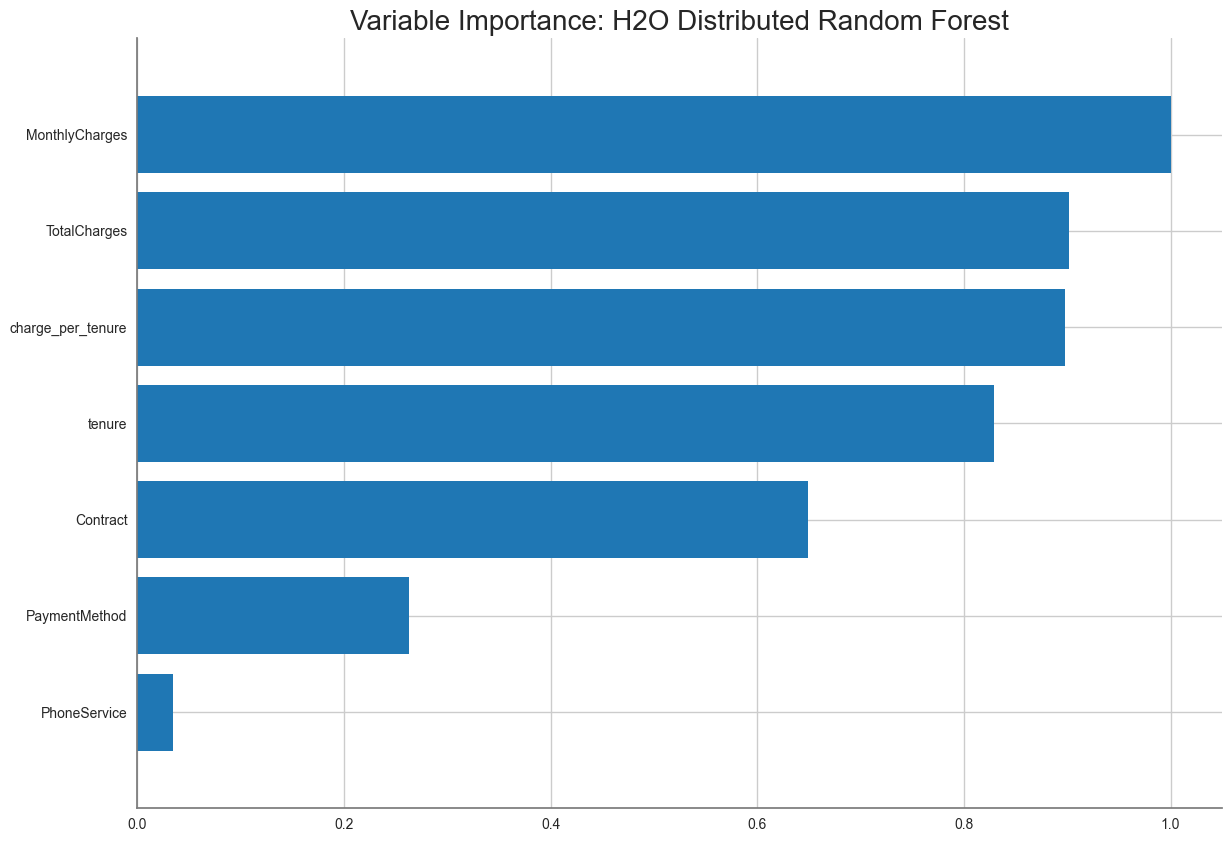

,variable,relative_importance,scaled_importance,percentage
0,MonthlyCharges,13560.426758,1.000000,0.218599
1,TotalCharges,12232.633789,0.902083,0.197195
2,charge_per_tenure,12171.467773,0.897573,0.196209
3,tenure,11239.304688,0.828831,0.181182
4,Contract,8799.596680,0.648917,0.141853
5,PaymentMethod,3565.933350,0.262966,0.057484
6,PhoneService,463.936249,0.034213,0.007479


<Figure size 800x550 with 0 Axes>

In [15]:
# H2O feature importances
rf.varimp_plot()
rf.varimp(use_pandas=True)

In [16]:
# Side-by-side with the pycaret leaderboard's top model (by AUC).
pycaret_top = leaderboard.iloc[0]
comparison = pd.DataFrame({
    'package': ['pycaret', 'H2O'],
    'model': [pycaret_top['Model'], 'Random Forest'],
    'test_AUC': [round(float(pycaret_top['AUC']), 4), round(float(h2o_auc), 4)],
    'test_accuracy': [round(float(pycaret_top['Accuracy']), 4), round(float(h2o_acc), 4)],
})
comparison

,package,model,test_AUC,test_accuracy
0,pycaret,Gradient Boosting Classifier,0.8366,0.7915
1,H2O,Random Forest,0.7910,0.7823


In [17]:
h2o.cluster().shutdown()

H2O session _sid_8e22 closed.


## Challenges 3-5: class-based module, command-line input, and the unmodified data

`predict_churn.py` now holds a `ChurnPredictor` class (challenge 3), accepts a `--file` argument via argparse so the user can choose the input file at the command line (challenge 4), and can preprocess the *unmodified* churn data by applying the same week 2 steps, so `new_churn_data_unmodified.csv` works (challenge 5). Below I run the class on both the prepared and the unmodified files to show they produce the same predictions.

In [18]:
import importlib
import predict_churn
importlib.reload(predict_churn)

predictor = predict_churn.ChurnPredictor()

print('From the prepared data (new_churn_data.csv):')
prepared = predictor.load_data('new_churn_data.csv')
display(predictor.make_predictions(prepared))

print('From the unmodified data (new_churn_data_unmodified.csv):')
unmodified = predictor.load_data('new_churn_data_unmodified.csv')
display(predictor.make_predictions(unmodified))

Transformation Pipeline and Model Successfully Loaded
From the prepared data (new_churn_data.csv):


,churn_probability,churn_prediction,train_percentile
customerID,,,
9305-CKSKC,0.4377,No churn,74.7
1452-KNGVK,0.0671,No churn,29.3
6723-OKKJM,0.0926,No churn,36.4
7832-POPKP,0.2723,No churn,59.6
6348-TACGU,0.0958,No churn,37.1


From the unmodified data (new_churn_data_unmodified.csv):


,churn_probability,churn_prediction,train_percentile
customerID,,,
9305-CKSKC,0.4377,No churn,74.7
1452-KNGVK,0.0671,No churn,29.3
6723-OKKJM,0.0926,No churn,36.4
7832-POPKP,0.2723,No churn,59.6
6348-TACGU,0.0217,No churn,9.9


# Task 1E - Summary

When it comes to the process, I went ahead and did a quick compare of data and the first thing that I noticed was that the training data and the new scoring data (new_churn_data.csv) did not share the same schema. The week 2 data one-hot encoded PaymentMethod into four Payment columns and called the newly engineered feature `charges_per_month_tenure`, while the new data keeps PaymentMethod as a single integer column and calls the engineered feature "charge_per_tenure". The two `head()` cells near the top of the notebook show this difference directly. A saved model should expect the same columns it was trained on, so if I had trained on the week 2 schema the model would most likely fail on the new data. To match them, I collapsed the four one-hot columns back into one integer PaymentMethod (using the same codes the new data uses) and renamed the engineered column to "charge_per_tenure", giving a training set whose features line up with the new data.

I then used pycaret's `setup` and `compare_models` for autoML. Since churn is imbalanced (about 27% churners), I sorted by AUC instead of the default accuracy, because a model that always predicts "no churn" already gets roughly 73% accuracy. Pycaret found the Gradient Boosting Classifier as the top model by AUC (about 0.84 cross-validated AUC, roughly 0.79 accuracy). I finalized that model and saved it to churn_model.pkl, then wrote predict_churn.p` with a make_predictions function that loads the model and returns the probability of churn for each row.

When it comes to the results, on the five new customers the model produced churn probabilities of about 0.44, 0.07, 0.09, 0.27, and 0.10 against the true labels [1, 0, 0, 1, 0]. At the default threshold, every row is predicted "No churn," so it correctly classifies the three non-churners but misses both actual churners, matching only 3 of 5. Both true churners have the two highest probabilities, so the model ranks them correctly; which brings back the feedback from Week 4 about lowering the threshold. I went ahead and compared two lower cutoffs against the default, at 0.40 the first churner at 0.44 is caught, moving from 3/5 to 4/5 correct and lifting churn recall from 0.00 to 0.50. And at 0.25 the second churner at 0.27 is also caught, so all five rows are classified correctly (5/5) with churn recall of 1.00. On this sample, precision stays at 1.00 across all three thresholds but mainly due to the three non-churners scoring very low (all at or below 0.10) where this could've been different on a larger dataset rather than the 5 rows we have.